# Practical 2: Recognising and plotting probability distributions
## Exploring student attainment in schools

This week is focussed on linking probability distributions to the data using some common functions in Python.  

## Learning Outcomes

- Load and tidy a new dataset in Python, building on what you did in Practical 1.
- Plot histograms and recognise the features of a normal distribution.
- Use Q-Q plots to check whether a dataset is (approximately) normally distributed.
- Standardise a variable into z-scores, and use them to flag unusual values.
- Use a fitted normal distribution to calculate probabilities, and compare them with what's actually in the data.

## Starting the Practical

As per last week, download the notebook to your chosen folder, then open `JupyterLab` (which will be running in Podman/Docker), or [VS Code](https://code.visualstudio.com/), to run the code yourself. 

*Optionally* if you want to save the completed notebook to your Github repo, you can `add`, `commit`, and `push` the notebook in Git after you download it. When you're done for the day, save your changes to the file (This is very important!), then `add`, `commit`, and `push` your work to save the completed notebook.

## Task 1 - Import the Python packages 

We are going to import some common python packages. 

In [1]:
import pandas as pd # pandas is a library for data manipulation
import matplotlib.pyplot as plt # matplotlib is a library for data visualisation
import numpy as np # numpy is a library for numerical computing
from pathlib import Path # pathlib is a library for working with file paths

## Task 2 — Read the data in

We are going to look at schools performance data in England.

The data is sourced from gov.uk [here](https://www.compare-school-performance.service.gov.uk/download-data) - HOWEVER I have also saved a copy of the relevant dataset to the Github repo which you can load directly in the code below. In this notebook we're using the performance table for academic year 2022/23: 'Performancetables_130242/2022-2023'.

If you do want to download the data directly from the gov.uk website then you need to choose the academic year '2022 to 2023', then 'All of England', then 'Key stage 4 results (final)'. Then you'll want to download the 'Data in CSV format' and also 'Explanation of terminology used in the data files'.

In [3]:
data_path = 'data/Performancetables_130242/2022-2023/'

# Read CSV file, handling common missing value entries
na_vals = ["", "NA", "SUPP", "NP", "NE", "SP", "SN", "SUPPMAT"]
df_ks4 = pd.read_csv(data_path + "england_ks4final.csv",
    na_values = na_vals
)

info_cols = ['RECTYPE', 'LEA', 'SCHNAME', 'TOTPUPS']
ebaccs_cols = ['EBACCAPS', 'EBACCAPS_LO', 'EBACCAPS_MID', 'EBACCAPS_HI']

df = df_ks4[info_cols + ebaccs_cols]

# work on a copy of the dataframe to avoid SettingWithCopyWarning
df = df.copy()

df.head()

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_40176/2869934649.py:5: DtypeWarning: Columns (75,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,144,145,146,147,148,149,150,151,152,177,178,179,180,181,182,183,186,187,188,189,190,191,192,194,195,196,198,199,200,202,203,204,206,207,208,210,211,212,214,215,216,218,219,220,222,223,224,230,233,234,235,236,237,238,239,242,243,244,245,246,247,248,251,252,253,254,255,256,257,266,267,268,269,270,271,272,281,282,283,284,285,286,287,296,297,298,299,300,301,302,311,312,313,314,315,316,317,335,336,337,340,341,342,345,346,347,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ks4 = pd.read_csv(data_path + "england_ks4final.csv",


,RECTYPE,LEA,SCHNAME,TOTPUPS,EBACCAPS,EBACCAPS_LO,EBACCAPS_MID,EBACCAPS_HI
0,1,201.0,City of London School,1045,2.10,NaN,NaN,NaN
1,1,201.0,City of London School for Girls,739,1.51,NaN,NaN,NaN
2,1,201.0,David Game College,365,0.56,NaN,NaN,NaN
3,4,201.0,NaN,0,NaN,NaN,NaN,NaN
4,1,202.0,Acland Burghley School,1163,4.62,1.91,3.81,6.87




You might be wondering why I've chosen the columns `info_cols` and `ebaccs_cols`. In open source datasets the column headers might be obscure, or difficult to decipher - but typically metadata will be provided that explains the meaning. 

Looking at the metadata (which you can see in '../data/ks4_meta.xlsx') we can see the full meaning of each column header: 

| Variable name   | Meaning                                                                                  |
|-----------------|------------------------------------------------------------------------------------------|
| RECTYPE         | Record type (1=mainstream school; 2=special school; 4=local authority; 5=National (all schools); 7=National (maintained schools)) |
| LEA             | Local authority                                                                          |
| SCHNAME         | School name                                                                              |
| TOTPUPS         | Number of pupils on roll (all ages)                                                      |
| EBACCAPS        | Average EBacc APS score per pupil                                                        |
| EBACCAPS_LO     | Average EBacc APS score per pupil with low prior attainment                              |
| EBACCAPS_MID    | Average EBacc APS score per pupil with middle prior attainment                           |
| EBACCAPS_HI     | Average EBacc APS score per pupil with high prior attainment                             |


<!-- - 'RECTYPE' = Record type (1=mainstream school; 2=special school; 4=local authority; 5=National (all schools); 7=National (maintained schools))
- 'LEA' = Local authority 
- 'SCHNAME' = School name 
- 'TOTPUPS' = Number of pupils on roll (all ages)
- 'EBACCAPS' = Average EBacc APS score per pupil
- 'EBACCAPS_LO' = Average EBacc APS score per pupil with low prior attainment
- 'EBACCAPS_MID' = Average EBacc APS score per pupil with middle prior attainment
- 'EBACCAPS_HI' = Average EBacc APS score per pupil with high prior attainment -->

EBacc stands for English Baccalaureate. It is a measure of students school grades calculated as an average score across a set number of subjects. It is used by the government as a performance indicator of English schools. You can read more about it [here](https://en.wikipedia.org/wiki/English_Baccalaureate#:~:text=Added%20together%2C%20this%20gives%20a,for%20girls%202018%20was%204.33.).

The EBacc has a minimum score of 0, which indicates very poor performance, and a maximum score of 9, which indicates very high performance. 

## Tidying up

Before we can plot anything, this file needs the same two checks you already did properly last week - data types, and which rows actually belong in the data.  



In [4]:
df.dtypes

RECTYPE           int64
LEA             float64
SCHNAME          object
TOTPUPS          object
EBACCAPS        float64
EBACCAPS_LO     float64
EBACCAPS_MID    float64
EBACCAPS_HI     float64
dtype: object

In [5]:
df.loc[:, ebaccs_cols] = df.loc[:, ebaccs_cols].apply(pd.to_numeric, errors='coerce')
df['TOTPUPS'] = pd.to_numeric(df['TOTPUPS'], errors='coerce').fillna(0).astype('int64')

In [6]:
# record types 4, 5 and 7 are aggregated local authority / national rows,
# not individual schools - keep 1 (mainstream) and 2 (special) only
df = df[df['RECTYPE'].isin([1, 2])].copy()

rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 5657, Columns: 8


## Task 3 — Plot the distribution

Let's try plotting the Average EBacc APS score per pupil.

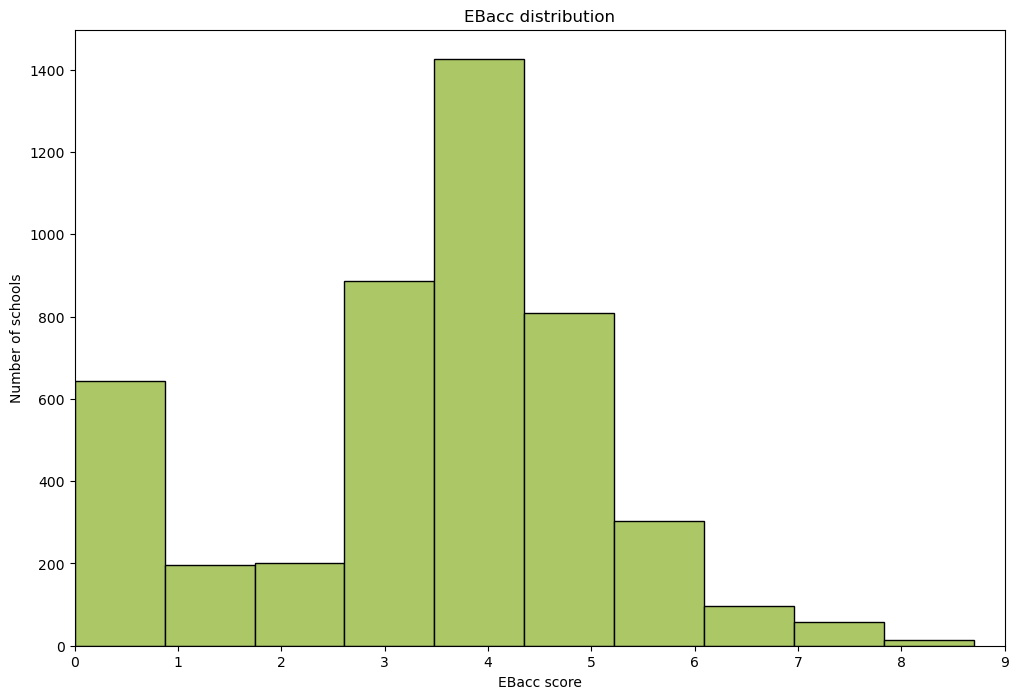

In [7]:
n_bins = 10
fig, ax = plt.subplots(figsize=(12, 8))

ax.hist(df['EBACCAPS'].dropna(), bins=n_bins, color='#abc766', edgecolor='black')
ax.set_title('EBacc distribution')
ax.set_xlabel('EBacc score')
ax.set_ylabel('Number of schools')
ax.set_xlim(0,9) # the EBacc has a maximum score of 9

plt.show()

#### Question

What do you observe from this histogram? Because the bins are quite large it's difficult to get a sense of the distribution - try changing this to get a better idea of the data spread. 

#### Answer 

In [8]:
## Edit this code 

# n_bins = ??
# fig, ax = plt.subplots(figsize=(12, 8))

# ax.hist(df['EBACCAPS'].dropna(), bins=n_bins, color='#abc766', edgecolor='black')
# ax.set_title('EBacc distribution')
# ax.set_xlabel('EBacc score')
# ax.set_ylabel('Number of schools')  
# ax.set_xlim(0,9) # the EBacc has a maximum score of 9

# plt.show()

# Task 4 — Check for normality

Looking at the histogram does the data look normally distributed?

Remember the key features of the normal distribution:

- Data is continuous 
  - it is something you measure not something you count
- Data is equally likely to be larger or smaller than average 
  - symmetric
- Characteristic size, all data points are close to the mean 
  - single peak
- There is less data further away from the mean 
  - smooth tails on both sides

One way to consider whether it is normally distributed is to overlay the normal distribution on top.

In Python we can use the package `scipy.stats` which has functions for generating probability density functions for common distributions. You can see which common distributions [here](https://docs.scipy.org/doc/scipy/reference/stats.html).

In [9]:
import scipy.stats as sps # scipy.stats is a library for statistical functions

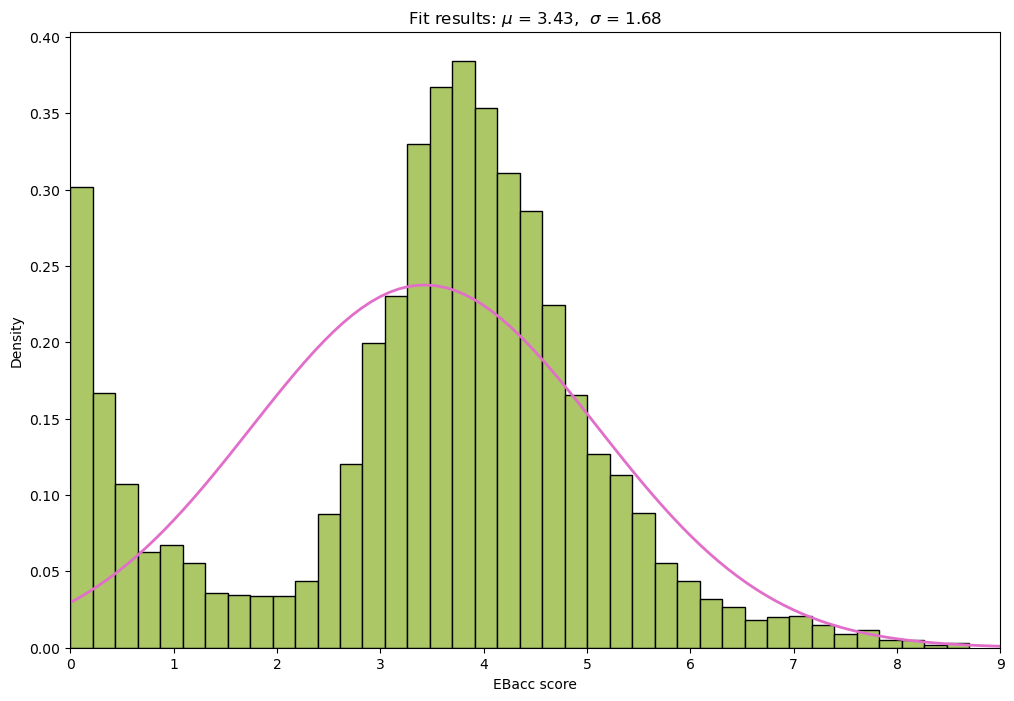

In [10]:
# first let's get the mean and stand deviation
mu = df['EBACCAPS'].dropna().mean()
std = df['EBACCAPS'].dropna().std()

## Create the plot

# plot the histogram
plt.figure(figsize=(12, 8))
plt.hist(df['EBACCAPS'], bins=40, density=True, color='#abc766', edgecolor='black')

# plot the Probability Density Function (PDF)
xmin = 0
xmax = 9
x = np.linspace(xmin, xmax, 100)
p = sps.norm.pdf(x, mu, std)
plt.plot(x, p, linewidth=2, color="#e16fca")

plt.title(f"Fit results: $\\mu$ = {mu:.2f},  $\\sigma$ = {std:.2f}")
plt.xlim(0, 9)
plt.xlabel("EBacc score")
plt.ylabel("Density")

plt.show()

Note that this time we plot the histogram with `density=True` - this scales the histogram data. 

Another way to think about whether something is normally distirbuted is to look at the Q-Q plot. 

## Q-Q plot

A Q-Q plot is used to compare two probability distributions, by comparing their quantiles.It can be used to see if data follows a normal distribution. You can read a bit more about Q-Q plots [here](https://www.datacamp.com/tutorial/qq-plot).

#### Question

Thinking about the characteristics of a normal distribution, what would you expect the Q-Q plot of perfectly normally distributed dataset to look like? 

#### Answer

If the data is normally distributed, the points in the Q-Q plot will lie close to a straight diagonal line. This happens because the quantiles of the sample match the quantiles of the theoretical normal distribution.


The results of the Q-Q plot can help us to understand the dataset: 

- For perfectly normal data: *points fall almost exactly on the diagonal line*
- Heavy tails (more extreme values than normal): *points curve away at the end*
- Light tails (fewer extreme values than normal): *points bend inward at the ends*
- Skewed data: *points systematically deviate above or below the line*

We can plot the Q-Q plot ourselves. Note that before we Q-Q plot the sample data we will need to normalise it - this accounts for the fact that our data is not centred around 0. We will shortly (Task 5) look at normalising the data more explictly. 

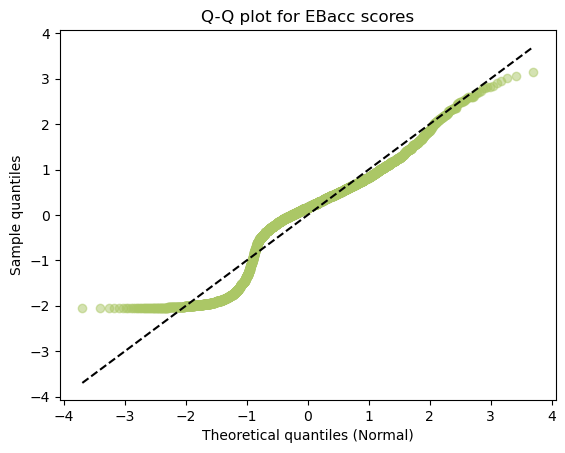

In [11]:
# Drop missing values
data = df['EBACCAPS'].dropna().values
n = len(data)

# normalise the data
data = (data - np.mean(data)) / np.std(data)

# Sort the sample data
sample_quantiles = np.sort(data)

# Compute plotting positions (probabilities)
p = (np.arange(1, n+1) - 0.5) / n

# Compute theoretical quantiles from standard normal
theoretical_quantiles = sps.norm.ppf(p)

# Plot
plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.5, color='#abc766')
plt.plot(theoretical_quantiles, theoretical_quantiles, color='black', linestyle='--')  # reference line
plt.title("Q-Q plot for EBacc scores")
plt.xlabel("Theoretical quantiles (Normal)")
plt.ylabel("Sample quantiles")

plt.show()

Ok, so in case it wasn't clear from the previous plot we can see that the data definitely isn't perfectly normal. 

# Task 5 — Explain the skew

If you remember above this dataset includes schools of two different types, we have mainstream schools and special schools. 'special schools' refers to schools which cater to students with special educational needs. Let's see what happens when we split our histogram according to the type of school.



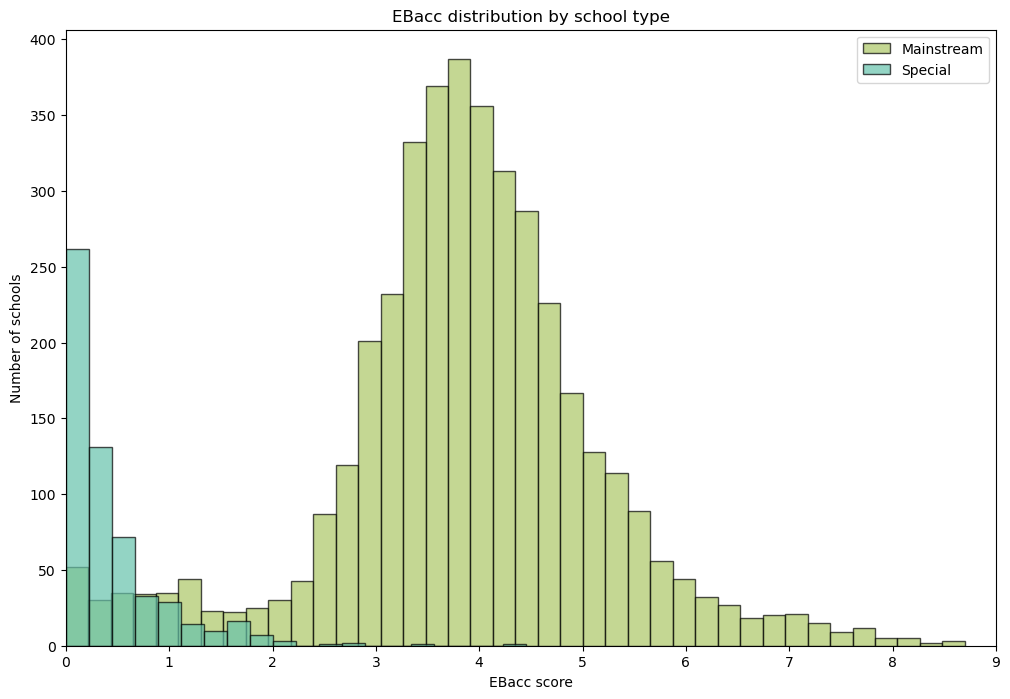

In [12]:
# histogram of # plot histogram of EBACCAPS by RECTYPE
n_bins = {1:40, 2:20}
fig, ax = plt.subplots(figsize=(12, 8))
for rectype, color, label in zip([1, 2], ['#abc766', '#66c2ab'], ['Mainstream', 'Special']):
    ax.hist(df_ks4.loc[df_ks4['RECTYPE'] == rectype, 'EBACCAPS'].dropna(), bins=n_bins[rectype], alpha=0.7, color=color, edgecolor='black', label=label)
ax.set_title('EBacc distribution by school type')
ax.set_xlabel('EBacc score')
ax.set_ylabel('Number of schools')
ax.set_xlim(0,9)
ax.legend()

plt.show()

Note that I've played with the number of total bins for each group so that the histograms look nice.

Looking now at the histogram it becomes clear that the skewness of the data is caused by the different school types. 

## Splitting the data by school type

Let's try again to see if the data is normal - this time splitting the dataset according to the school type.

#### Question

Split the dataset according to the school type. 

In [13]:
# # mainstream school
# df1 = df[??]

# # special schools
# df2 = df[??]

#### Answer

In [14]:
# mainstream school
df1 = df[df['RECTYPE'] == 1].copy()

# special schools
df2 = df[df['RECTYPE'] == 2].copy()

## Q-Q plot for mainstream schools

#### Question

In [15]:
# # Drop missing values
# data = df1['EBACCAPS'].dropna().values
# n = len(data)

# # normalise the data
# data = (data - np.mean(data)) / np.std(data)

# # Sort the sample data
# sample_quantiles = ??

# # Compute plotting positions (probabilities)
# p = ??

# # Compute theoretical quantiles from standard normal
# theoretical_quantiles = ??

# # Plot
# plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.5, color='#abc766')
# plt.plot(theoretical_quantiles, theoretical_quantiles, color='black', linestyle='--')  # reference line
# plt.title("Mainstream schools: Q-Q plot for EBacc scores")
# plt.xlabel("Theoretical quantiles (Normal)")
# plt.ylabel("Sample quantiles")

# plt.show()

#### Answer

In [16]:
# # Drop missing values
# data = df2['EBACCAPS'].dropna().values
# n = len(data)

# # normalise the data
# data = (data - np.mean(data)) / np.std(data)

# # Sort the sample data
# sample_quantiles = ??

# # Compute plotting positions (probabilities)
# p = ??

# # Compute theoretical quantiles from standard normal
# theoretical_quantiles = ??

# # Plot
# plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.5, color='#abc766')
# plt.plot(theoretical_quantiles, theoretical_quantiles, color='black', linestyle='--')  # reference line
# plt.title("Special schools: Q-Q plot for EBacc scores")
# plt.xlabel("Theoretical quantiles (Normal)")
# plt.ylabel("Sample quantiles")

# plt.show()

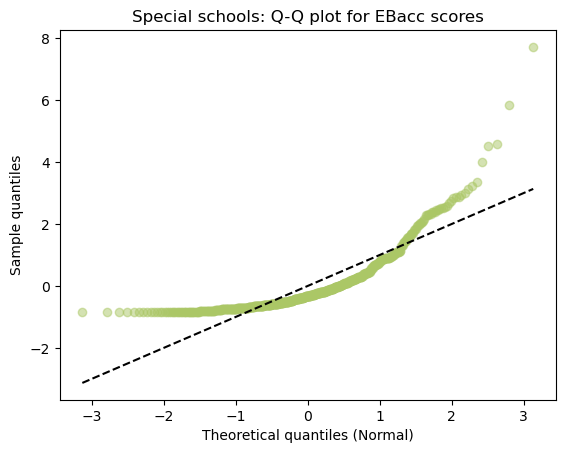

In [17]:
# Drop missing values
data = df2['EBACCAPS'].dropna().values
n = len(data)

# normalise the data
data = (data - np.mean(data)) / np.std(data)

# Sort the sample data
sample_quantiles = np.sort(data)

# Compute plotting positions (probabilities)
p = (np.arange(1, n+1) - 0.5) / n

# Compute theoretical quantiles from standard normal
theoretical_quantiles = sps.norm.ppf(p)

# Plot
plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.5, color='#abc766')
plt.plot(theoretical_quantiles, theoretical_quantiles, color='black', linestyle='--')  # reference line
plt.title("Special schools: Q-Q plot for EBacc scores")
plt.xlabel("Theoretical quantiles (Normal)")
plt.ylabel("Sample quantiles")

plt.show()

Looking at the resultant Q-Q plots what can we say about the data? We see that the mainstream schools is a skewed dataset, whilst the special schools dataset has a heavy tail.

# Task 6 — Standardise with z-scores

So far we've described scores in their own units — an EBacc point. A z-score puts every value on a common scale instead - how many standard deviations a value sits from the mean.

$$z = \frac{x - \mu}{\sigma}$$

We've just seen that mainstream and special schools sit on quite different distributions, so we standardise mainstream schools (`df1`) against their own mean and standard deviation, rather than mixing the two populations together.



In [18]:
mu1 = df1['EBACCAPS'].dropna().mean()
std1 = df1['EBACCAPS'].dropna().std()

df1['EBACCAPS_z'] = (df1['EBACCAPS'] - mu1) / std1

df1[['SCHNAME', 'EBACCAPS', 'EBACCAPS_z']].dropna() \
  .sort_values('EBACCAPS_z', ascending=False) \
  .head(10)

,SCHNAME,EBACCAPS,EBACCAPS_z
365,The Henrietta Barnett School,8.70,3.698521
867,Wilson's School,8.56,3.591566
383,"Queen Elizabeth's School, Barnet",8.50,3.545729
481,St Olave's and St Saviour's Grammar School,8.37,3.446414
3496,Kendrick School,8.29,3.385297
1621,Altrincham Grammar School for Girls,8.19,3.308901
969,King Edward VI Camp Hill School for Boys,8.17,3.293622
742,The Tiffin Girls' School,8.16,3.285983
3835,Chelmsford County High School for Girls,8.13,3.263064
3503,Reading School,8.11,3.247785


That's the ten mainstream schools furthest above the mean, in standard-deviation terms. `z = 0` is a school scoring exactly the mean; `z = 1` is one standard deviation above it.

#### Question

Adapt the code above to find the ten schools furthest below the mean instead.

In [19]:
# df1[['SCHNAME', 'EBACCAPS', 'EBACCAPS_z']].dropna() \
#   .sort_values('EBACCAPS_z', ascending=??) \
#   .head(10)

In [20]:
df1[['SCHNAME', 'EBACCAPS', 'EBACCAPS_z']].dropna() \
  .sort_values('EBACCAPS_z', ascending=True) \
  .head(10)

,SCHNAME,EBACCAPS,EBACCAPS_z
2770,Kings Bournemouth,0.0,-2.947927
1276,Progress Schools - Toxteth,0.0,-2.947927
5327,Brookes UK,0.0,-2.947927
1064,The National Mathematics and Science College,0.0,-2.947927
301,Eifa International School,0.0,-2.947927
2346,Learning4Life-GY,0.0,-2.947927
5210,Kings Education (Oxford),0.0,-2.947927
1536,Beis Ruchel Girls School,0.0,-2.947927
3423,Maranatha Christian School,0.0,-2.947927
1459,Manchester Vocational and Learning Academy,0.0,-2.947927


Standardising doesn't change the shape of a distribution, only its location and scale — everything just shifts to be centred on 0 with a spread of 1. You can see that by plotting the z-scores themselves:



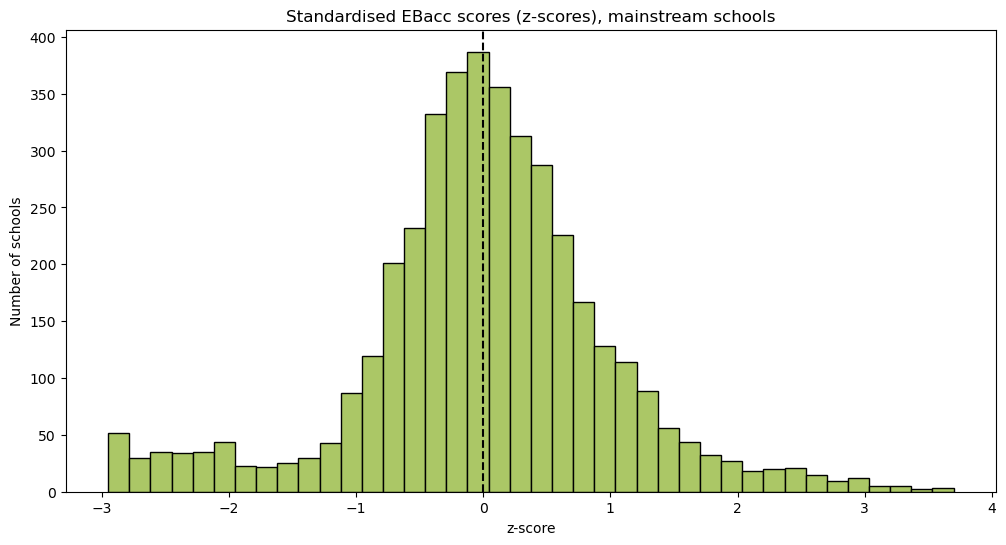

In [21]:
plt.figure(figsize=(12, 6))
plt.hist(df1['EBACCAPS_z'].dropna(), bins=40, color='#abc766', edgecolor='black')
plt.axvline(0, color='black', linestyle='--')
plt.title('Standardised EBacc scores (z-scores), mainstream schools')
plt.xlabel('z-score')
plt.ylabel('Number of schools')

plt.show()

That's the same mild skew you saw in the mainstream Q-Q plot above, just relabelled onto a scale centred on 0 with a spread of 1.

A common rule of thumb flags anything with $|z| > 2$ as unusually far from the mean.

#### Question

How many mainstream schools have $|z| > 2$?

In [22]:
# (df1['EBACCAPS_z'].abs() > ??).sum()

In [23]:
(df1['EBACCAPS_z'].abs() > 2).sum()

np.int64(336)

# Task 7 — Calculate a probability from the normal distribution

If we're willing to accept `EBACCAPS` is approximately normally distributed, we can answer questions like "what proportion of schools would we expect to score above 6.0?" using nothing but a mean and a standard deviation, without needing the raw data at all.

The Q-Q plots above showed the whole dataset is clearly not normal — but restricting to mainstream schools removed the second hump caused by special schools, which is why we've been standardising `df1` rather than the full dataset since the z-scores section above. Even mainstream schools weren't a perfect diagonal line on the Q-Q plot, but the whole point of the probaility distirbution to be able to aprpoximatethe data using a matehmatical distirbution, hence simplifying the analysis. So treat what follows as a working approximation, not a guarantee.



In [24]:
print(f"Mainstream schools:  mu = {mu1:.2f}, std = {std1:.2f}")

Mainstream schools:  mu = 3.86, std = 1.31




`scipy.stats.norm` gives us probabilities directly from those two numbers: `.cdf(x, mu, std)` returns $P(X \leq x)$, and `.sf(x, mu, std)` ("survival function") returns $P(X > x)$, i.e. $1 - \text{cdf}(x)$. In R, the equivalent is `pnorm(x, mu, std)` and `pnorm(x, mu, std, lower.tail = FALSE)`.



In [25]:
threshold = 6.0

p_above = sps.norm.sf(threshold, mu1, std1)
print(f"Normal model:  P(EBacc > {threshold}) = {p_above:.3f}")

# how does that compare to what's actually in the data?
empirical = (df1['EBACCAPS'] > threshold).mean()
print(f"Raw sample: proportion of mainstream schools actually above {threshold} = {empirical:.3f}")

Normal model:  P(EBacc > 6.0) = 0.051
Raw sample: proportion of mainstream schools actually above 6.0 = 0.044


Those two numbers should be reasonably close — much closer than they would be on the full, mixed dataset — but probably still not identical. That gap is the price of the normality assumption.

We can also find the probability of falling between two values, by subtracting one CDF from another: $P(a < X < b) = \text{cdf}(b) - \text{cdf}(a)$.

#### Question

What proportion of mainstream schools would the normal model predict scoring between 4 and 6 — and what proportion actually do, in the raw data?

In [26]:
# lower, upper = 4, 6
# p_between = sps.norm.cdf(??, mu1, std1) - sps.norm.cdf(??, mu1, std1)
# print(f"Normal model:  P({lower} < EBacc < {upper}) = {p_between:.3f}")

# # how does that compare to what's actually in the data?
# empirical_between = ((df1['EBACCAPS'] > lower) & (df1['EBACCAPS'] < ??)).mean()
# print(f"Raw sample:    proportion of mainstream schools actually between {lower} and {upper} = {empirical_between:.3f}")

In [27]:
lower, upper = 4, 6
p_between = sps.norm.cdf(upper, mu1, std1) - sps.norm.cdf(lower, mu1, std1)
print(f"Normal model:  P({lower} < EBacc < {upper}) = {p_between:.3f}")

# how does that compare to what's actually in the data?
empirical_between = ((df1['EBACCAPS'] > lower) & (df1['EBACCAPS'] < upper)).mean()
print(f"Raw sample:    proportion of mainstream schools actually between {lower} and {upper} = {empirical_between:.3f}")

Normal model:  P(4 < EBacc < 6) = 0.406
Raw sample:    proportion of mainstream schools actually between 4 and 6 = 0.378


As with the single-threshold example above, these two numbers should be close but not identical — the gap is the same price of the normality assumption.

# Extension

### EBacc by prior attainment 
If you've finished looking at the histogram plots of the EBacc data, try plotting the histograms of the columns 'EBACCAPS_LO', 'EBACCAPS_MID', 'EBACCAPS_HI'. What can you say about these data distributions? Does plotting the Q-Q plots help? 

#### Question

In [28]:
# n_bins = ??
# fig, ax = plt.subplots(3, 1, figsize=(12, 18))
# plot_names = ['EBacc low prior', 'EBacc mid prior', 'EBacc high prior']

# for i, col in ??:
#     ax[i].hist(df[col].dropna(), bins=n_bins, color='#abc766', edgecolor='black')
#     ax[i].set_title(plot_names[i])
#     ax[i].set_xlabel('EBacc score')
#     ax[i].set_ylabel('Number of schools')  
#     ax[i].set_xlim(0,9) # the EBacc has a maximum score of 9
    
# plt.show()

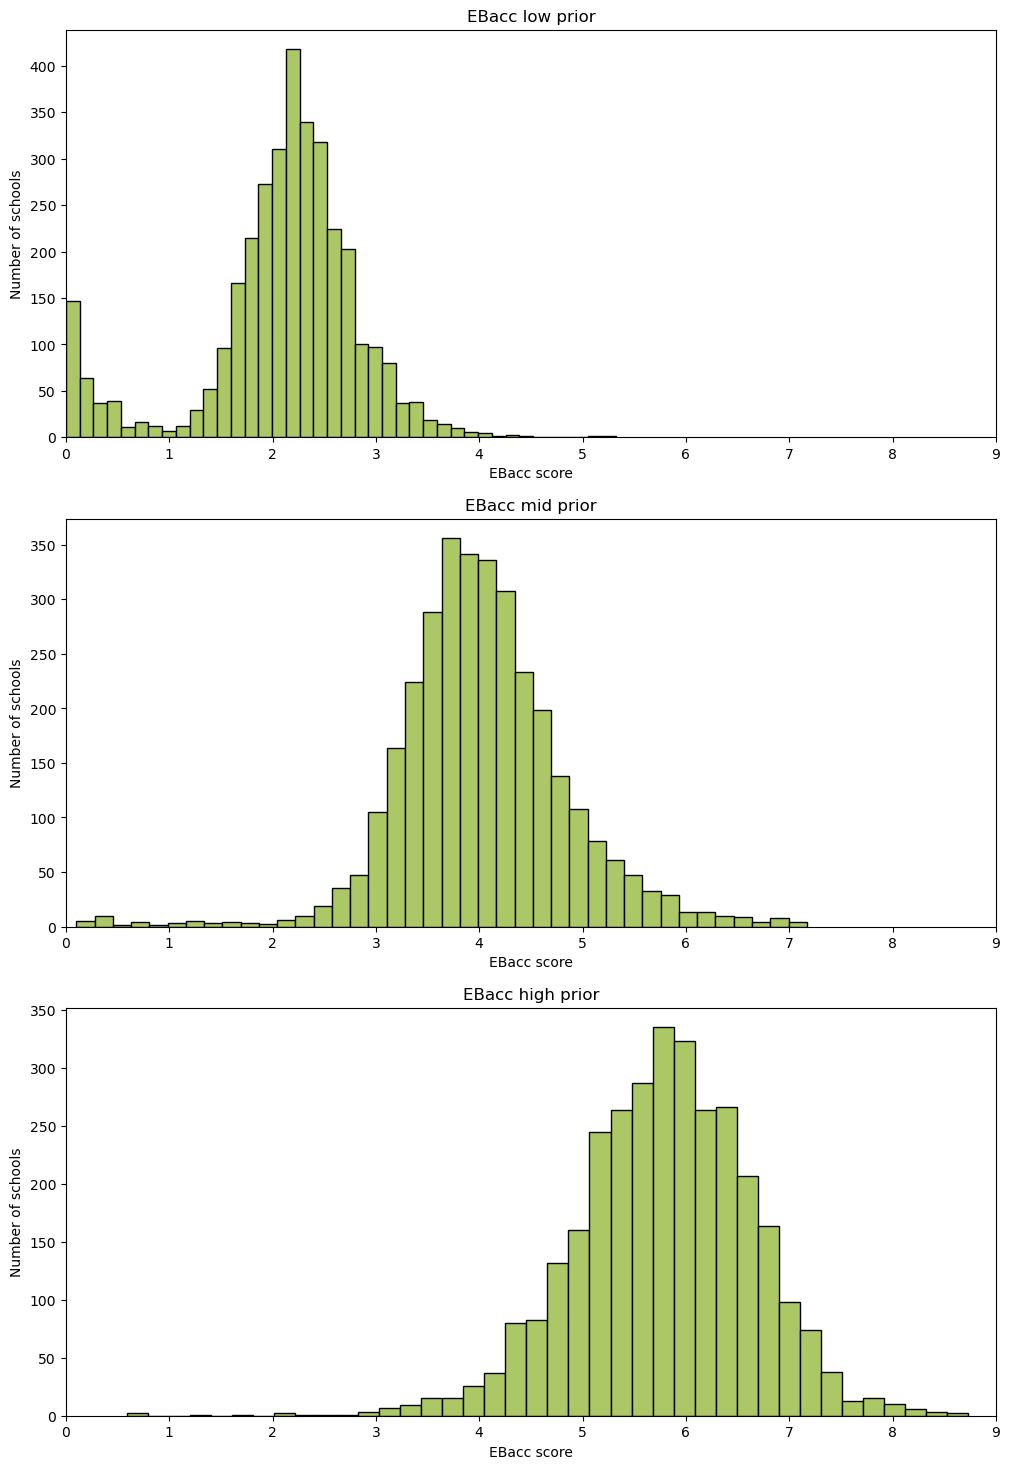

In [29]:
n_bins = 40
fig, ax = plt.subplots(3, 1, figsize=(12, 18))
plot_names = ['EBacc low prior', 'EBacc mid prior', 'EBacc high prior']

for i, col in enumerate(['EBACCAPS_LO', 'EBACCAPS_MID', 'EBACCAPS_HI']):
    ax[i].hist(df[col].dropna(), bins=n_bins, color='#abc766', edgecolor='black')
    ax[i].set_title(plot_names[i])
    ax[i].set_xlabel('EBacc score')
    ax[i].set_ylabel('Number of schools')  
    ax[i].set_xlim(0,9) # the EBacc has a maximum score of 9

plt.show()

### EBacc by school size 

If you've finished everything else, then you might like to look at some of the other variables in the dataset. Try plotting the EBacc scores against the total number of pupils ('TOTPUPS') - for example using a scatter plot - what can you say about this distribution? 

## You're Done!

You've completed the second QM practical session! 

Don’t worry about understanding every detail of the Python code — what matters most is knowing which functions to use for a specific task and knowing how to debug when it goes wrong. Remember, practice makes perfect :) 